# 🧩 The Mathematics of Extension Models: Mediation, Cannibalization & Synthesis

> **A math-first tour of how `mmm_framework` extends the additive MMM beyond a single channels→outcome
> equation.** This is notebook **06** in the math series. We derive the equations for three extension
> models, **fit two of them** on the Aurora dataset, and verify each claim against the **actual posterior**
> with `assert` statements — so "the notebook runs clean" *means* "the math recovered the truth."

The base model (notebooks 00–05) is a single linear map: every channel feeds **one** outcome through its
adstock·saturation·$\beta$ response, and the channels are otherwise independent of each other and of any
intermediate metric. Real marketing systems break both assumptions:

| | Extension | What it adds | The question it answers |
|---|---|---|---|
| **1** | **`NestedMMM`** (mediation) | a **mediator** (e.g. brand awareness) between channels and outcome | *How much of a channel's effect is **indirect** — built through awareness rather than sold directly?* |
| **2** | **`MultivariateMMM`** (cross-effects) | **several outcomes jointly**, with a cross-effect $\psi$ and correlated residuals | *Does one product **cannibalize** another? Do the products share a demand wave?* |
| **3** | **`CombinedMMM`** (synthesis) | multi-outcome **and** mediation together | *Both at once — multiple outcomes, each reached directly and via mediators.* |

These three are a **separate class hierarchy** (`BaseExtendedMMM`), *not* `BayesianMMM` subclasses. They
fit the **raw** outcome (no standardization), a **single time series** (one observation per period, no geo
panel), and — crucially — they all share **one media transform**, which we cover first.

In [1]:
import warnings, sys
warnings.filterwarnings("ignore")
import numpy as np
import matplotlib.pyplot as plt
from aurora import PALETTE, CHANNEL_COLORS   # brand colors for visual consistency
plt.rcParams.update({
    "figure.dpi": 110, "figure.figsize": (9, 4.2),
    "axes.grid": True, "grid.alpha": 0.18,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.edgecolor": "#cfc7bd", "axes.titleweight": "bold",
    "figure.facecolor": "white", "savefig.facecolor": "white", "font.size": 10,
})
ACCENT, INK, MUTED = PALETTE["accent"], PALETTE["ink"], PALETTE["muted"]

## 0. The shared media transform

Every extension model pushes each channel's raw spend $x_{c}$ through the **same** three-step transform
before it can affect anything (`BaseExtendedMMM._media_transform_apply`). Writing $s_c = \max_t x_{c,t}$
for the per-channel raw-spend scale (a data-fixed constant) and $\mathrm{adstock}_\alpha$ for the
**normalized** geometric carryover from notebook 01:

$$
u_{c,t}
\;=\;
f_{\mathrm{sat}}\!\Big(
  \mathrm{adstock}_{\alpha_c}\!\big( x_{c,t} / s_c \big)
\Big),
\qquad
f_{\mathrm{sat}}(z) = \frac{1}{1+e^{-\lambda_c z}}\;\;(\text{logistic}).
$$

The normalization $x_{c,t}/s_c$ puts spend in roughly $[0,1]$ so the logistic saturation operates with
**real curvature** rather than collapsing onto its flat $\approx 1$ tail. Each channel learns a carryover
$\alpha_c \sim \mathrm{Beta}(2,2)$ and a saturation slope $\lambda_c \sim \mathrm{Gamma}(3,1)$. The output
$u_{c,t}$ is the channel's **saturated effective exposure** — the thing every downstream coefficient
($\beta$, $\delta$, $\gamma$) multiplies. Holding this fixed across the three models is what makes them
*comparable*: they differ only in **how $u_{c,t}$ is wired to the outcome(s)**, which is exactly the math
this notebook is about.

We grade every model against the **Aurora** synthetic world, whose generative truth is known.

In [2]:
from aurora import generate_aurora, CHANNELS, PRODUCTS

aurora = generate_aurora()       # ~2 years weekly; known ground truth
X = aurora.media_matrix()        # (n_weeks, n_channels) raw spend
print("channels:", CHANNELS, "| products:", PRODUCTS)
print("X (spend):", X.shape, "| weeks:", len(aurora.weeks))

# Ground truth the models will be graded against.
print("\nTRUE mediated share (fraction of each channel's effect flowing via awareness):")
print(aurora.true_mediated_share.round(3).to_string())
print("\nTRUE total-effect ROAS:")
print(aurora.true_roas.round(3).to_string())

channels: ['TV', 'Search', 'Social', 'Display'] | products: ['Original', 'Cold Brew']
X (spend): (104, 4) | weeks: 104

TRUE mediated share (fraction of each channel's effect flowing via awareness):
TV         0.988
Display    0.967
Search     0.000
Social     0.000

TRUE total-effect ROAS:
TV         2.143
Search     0.664
Social     0.486
Display    2.111


## 1. Three causal structures, side by side

Before the equations, the **shape** of each model. The base model wires every channel straight to the
outcome. `NestedMMM` inserts a **mediator** $m$ (some channels reach the outcome *through* it, optionally
plus a direct shortcut). `MultivariateMMM` keeps direct wiring but models **two outcomes jointly** with a
cross-effect $\psi$ between them. (`CombinedMMM`, covered in §5, is (b) and (c) fused.)

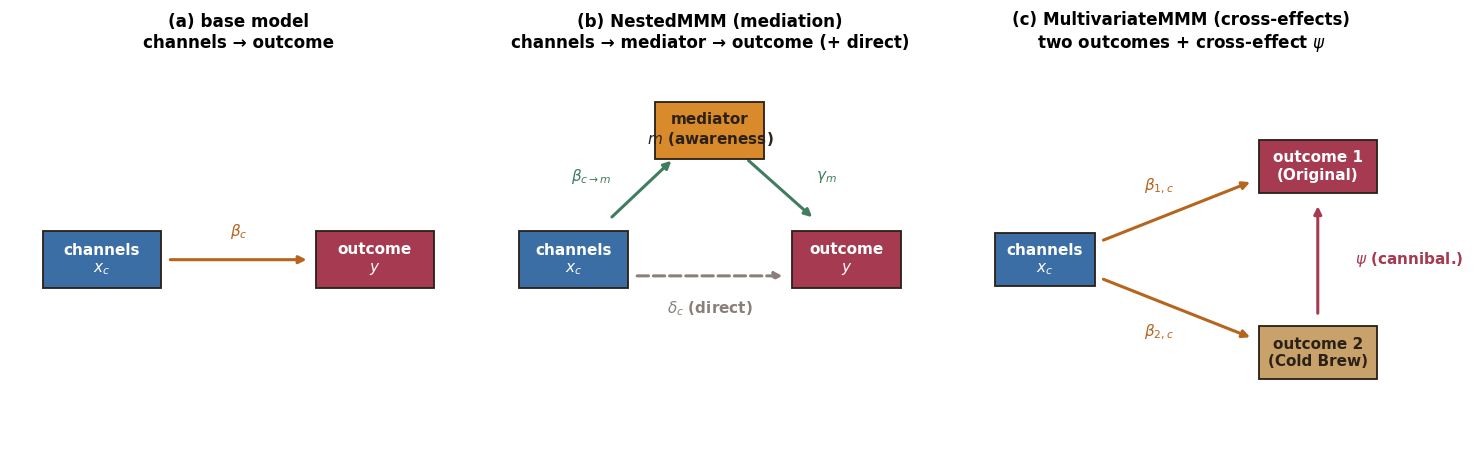

In [3]:
# Hand-drawn schematic of the three DAG structures (boxes + arrows).
fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.4))
for ax in axes:
    ax.set_xlim(0, 10); ax.set_ylim(0, 10); ax.axis("off")

def box(ax, x, y, w, h, text, fc, tc="white", fs=10):
    ax.add_patch(plt.Rectangle((x - w / 2, y - h / 2), w, h, facecolor=fc,
                               edgecolor=INK, lw=1.2, zorder=2))
    ax.text(x, y, text, ha="center", va="center", color=tc,
            fontsize=fs, fontweight="bold", zorder=3)

def arrow(ax, x0, y0, x1, y1, col=INK, ls="-", label=None, lx=0, ly=0):
    ax.annotate("", xy=(x1, y1), xytext=(x0, y0),
                arrowprops=dict(arrowstyle="-|>", color=col, lw=2.0, ls=ls,
                                shrinkA=6, shrinkB=6), zorder=1)
    if label:
        ax.text((x0 + x1) / 2 + lx, (y0 + y1) / 2 + ly, label, ha="center",
                va="center", color=col, fontsize=10, fontweight="bold", zorder=4)

# (a) Base model: channels -> outcome (direct only).
ax = axes[0]
box(ax, 2.0, 5, 2.6, 1.4, "channels\n$x_c$", PALETTE["sky"])
box(ax, 8.0, 5, 2.6, 1.4, "outcome\n$y$", PALETTE["berry"])
arrow(ax, 3.3, 5, 6.7, 5, col=ACCENT, label=r"$\beta_c$", ly=0.7)
ax.set_title("(a) base model\nchannels → outcome", fontsize=11)

# (b) Nested: channels -> mediator -> outcome (+ direct).
ax = axes[1]
box(ax, 2.0, 5, 2.4, 1.4, "channels\n$x_c$", PALETTE["sky"])
box(ax, 5.0, 8.2, 2.4, 1.4, "mediator\n$m$ (awareness)", PALETTE["amber"], tc=INK)
box(ax, 8.0, 5, 2.4, 1.4, "outcome\n$y$", PALETTE["berry"])
arrow(ax, 2.7, 5.9, 4.3, 7.6, col=PALETTE["leaf"], label=r"$\beta_{c\to m}$", lx=-1.1, ly=0.3)
arrow(ax, 5.7, 7.6, 7.4, 5.9, col=PALETTE["leaf"], label=r"$\gamma_m$", lx=1.0, ly=0.3)
arrow(ax, 3.2, 4.6, 6.8, 4.6, col=MUTED, ls="--", label=r"$\delta_c$ (direct)", ly=-0.8)
ax.set_title("(b) NestedMMM (mediation)\nchannels → mediator → outcome (+ direct)", fontsize=11)

# (c) Multivariate: channels -> two outcomes + cross-effect.
ax = axes[2]
box(ax, 2.0, 5, 2.2, 1.3, "channels\n$x_c$", PALETTE["sky"])
box(ax, 8.0, 7.3, 2.6, 1.3, "outcome 1\n(Original)", PALETTE["berry"])
box(ax, 8.0, 2.7, 2.6, 1.3, "outcome 2\n(Cold Brew)", PALETTE["crema"], tc=INK)
arrow(ax, 3.1, 5.4, 6.7, 7.0, col=ACCENT, label=r"$\beta_{1,c}$", lx=-0.4, ly=0.6)
arrow(ax, 3.1, 4.6, 6.7, 3.0, col=ACCENT, label=r"$\beta_{2,c}$", lx=-0.4, ly=-0.6)
arrow(ax, 8.0, 3.45, 8.0, 6.55, col=PALETTE["berry"], label=r"$\psi$ (cannibal.)", lx=2.0)
ax.set_title("(c) MultivariateMMM (cross-effects)\ntwo outcomes + cross-effect $\\psi$", fontsize=11)

plt.tight_layout(); plt.show()

## 2. `NestedMMM` — mediation (direct vs indirect effects)

In Aurora, **TV and Display barely sell anything directly**; they build **brand awareness**, and awareness
drives sales. A base model sees only the tiny direct slice and calls them weak. Mediation analysis recovers
their *real* (mostly indirect) value.

### The two structural equations

A nested model is **two stacked regressions**. With $u_{c,t}$ the saturated exposure from §0, a mediator
$m$ (e.g. awareness), the set $C(m)$ of channels routed to it, and a mediator intercept $a_m$:

$$
\textbf{(mediator)}\qquad
m_t \;=\; a_m \;+\; \sum_{c \in C(m)} \beta_{c\to m}\, u_{c,t},
$$

$$
\textbf{(outcome)}\qquad
y_t \;=\; a_y
\;+\; \underbrace{\sum_{m} \gamma_m\, m_t}_{\text{mediated paths}}
\;+\; \underbrace{\sum_{c} \delta_c\, u_{c,t}}_{\text{direct paths}}
\;+\; \varepsilon_t,
\qquad \varepsilon_t \sim \mathrm{Normal}(0,\sigma_y).
$$

Here $\beta_{c\to m}$ is the **channel → mediator** effect (positive-constrained: media builds awareness),
$\gamma_m$ is the **mediator → outcome** effect, and $\delta_c$ is the **direct** channel → outcome
shortcut. (Aurora's awareness $m$ is only observed in a sparse monthly survey — the model treats it as a
**latent series** and anchors it to the survey points wherever they exist; more in §2.2.)

### The effect decomposition

Substitute the mediator equation into the outcome equation. The coefficient on channel $c$'s exposure
$u_{c,t}$ becomes a sum over every path from $c$ to $y$:

$$
\text{coef}_c
\;=\;
\underbrace{\sum_{m} \beta_{c\to m}\,\gamma_m}_{\text{indirect (mediated)}}
\;+\;
\underbrace{\delta_c}_{\text{direct}}.
$$

Each **mediated path** contributes the *product* of its two edges $\beta_{c\to m}\gamma_m$ — the classic
product-of-coefficients mediation effect. The framework stores it as a Deterministic
`indirect_<channel>_via_<mediator>`. Define

$$
\text{indirect}_c = \sum_m \beta_{c\to m}\gamma_m,
\qquad
\text{total}_c = \text{indirect}_c + \delta_c,
\qquad
\boxed{\;\text{proportion mediated}_c = \dfrac{\text{indirect}_c}{\text{total}_c}\;}.
$$

A **proportion mediated near 1** means the channel works almost entirely *through* the mediator — its
direct sales are negligible. That is exactly what we expect for Aurora's TV and Display.

> **Why $\ge 2$ channels per mediator.** The indirect decomposition is only interesting when a mediator
> aggregates several channels: we map **TV and Display** (Aurora's brand channels) to awareness, and leave
> **Search and Social** as pure direct-response (not routed to any mediator, and with no direct term
> created for them either — so the decomposition simply does not apply to them, and their
> `proportion_mediated` is `NaN`). We therefore read the decomposition only for `["TV", "Display"]`.

In [4]:
from mmm_framework.mmm_extensions.models import NestedMMM
from mmm_framework.mmm_extensions.builders import MediatorConfigBuilder, NestedModelConfigBuilder

nested_cfg = (NestedModelConfigBuilder()
    .add_mediator(MediatorConfigBuilder("awareness")
                  .partially_observed(observation_noise=0.1)   # the sparse monthly survey
                  .with_positive_media_effect(sigma=1.0)        # beta_{c->m} >= 0 (media builds awareness)
                  .with_direct_effect(sigma=0.5)                # delta_c (direct shortcut)
                  .build())
    .map_channels_to_mediator("awareness", ["TV", "Display"])   # >= 2 channels -> real decomposition
    .build())

nested = NestedMMM(X, aurora.sales_total, list(CHANNELS), nested_cfg,
                   mediator_data={"awareness": aurora.awareness_survey}, index=aurora.weeks)
# macOS: cores=1 is required for the extension models. Seeded for reproducible asserts.
nested.fit(draws=500, tune=500, chains=2, cores=1, random_seed=0)
print("NestedMMM fitted.")

Initializing NUTS using jitter+adapt_diag...


Sequential sampling (2 chains in 1 job)


NUTS: [alpha_TV, lambda_TV, alpha_Search, lambda_Search, alpha_Social, lambda_Social, alpha_Display, lambda_Display, alpha_awareness, beta_media_to_awareness, beta_TV_to_awareness, beta_Display_to_awareness, awareness_obs_sigma, alpha_y, gamma_awareness, delta_direct_TV, delta_direct_Display, sigma_y]


Output()

Sampling 2 chains for 500 tune and 500 draw iterations (1_000 + 1_000 draws total) took 16 seconds.


We recommend running at least 4 chains for robust computation of convergence diagnostics


NestedMMM fitted.


In [5]:
# get_mediation_effects() returns the decomposition per channel.
med = nested.get_mediation_effects().set_index("channel")
print("columns:", list(med.columns))

brand = ["TV", "Display"]   # the channels routed through awareness
cols = ["direct_effect", "total_indirect", "total_effect", "proportion_mediated"]
display(med.loc[brand, cols].round(3))

columns: ['direct_effect', 'direct_effect_sd', 'total_indirect', 'total_effect', 'proportion_mediated', 'indirect_via_awareness']


,direct_effect,total_indirect,total_effect,proportion_mediated
channel,,,,
TV,0.053,151.080,151.134,1.000
Display,0.117,185.991,186.108,0.999


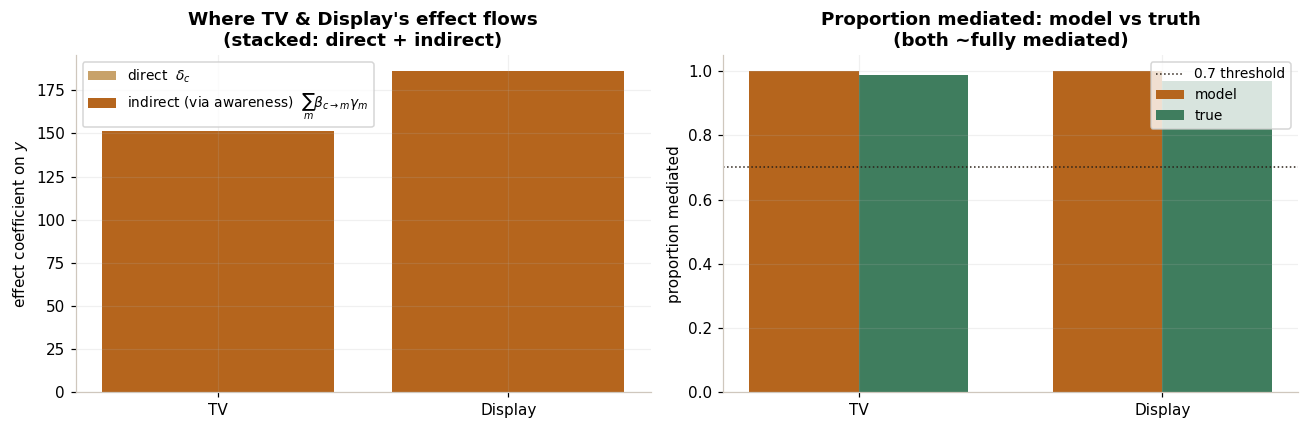

TV        proportion_mediated  model=1.000   true=0.988
Display   proportion_mediated  model=0.999   true=0.967


In [6]:
# Direct-vs-indirect stacked bars for the brand channels, + proportion_mediated vs the TRUE share.
fig, (axL, axR) = plt.subplots(1, 2, figsize=(12, 4))

direct = med.loc[brand, "direct_effect"].to_numpy()
indirect = med.loc[brand, "total_indirect"].to_numpy()
axL.bar(brand, direct, color=PALETTE["crema"], label=r"direct  $\delta_c$")
axL.bar(brand, indirect, bottom=direct, color=ACCENT,
        label=r"indirect (via awareness)  $\sum_m\beta_{c\to m}\gamma_m$")
axL.set_ylabel("effect coefficient on $y$")
axL.set_title("Where TV & Display's effect flows\n(stacked: direct + indirect)")
axL.legend(fontsize=9)

prop_model = med.loc[brand, "proportion_mediated"].to_numpy()
prop_true = aurora.true_mediated_share.loc[brand].to_numpy()
xpos = np.arange(len(brand)); w = 0.36
axR.bar(xpos - w / 2, prop_model, w, color=ACCENT, label="model")
axR.bar(xpos + w / 2, prop_true, w, color=PALETTE["leaf"], label="true")
axR.axhline(0.7, color=INK, ls=":", lw=1, label="0.7 threshold")
axR.set_xticks(xpos); axR.set_xticklabels(brand)
axR.set_ylim(0, 1.05); axR.set_ylabel("proportion mediated")
axR.set_title("Proportion mediated: model vs truth\n(both ~fully mediated)")
axR.legend(fontsize=9)
plt.tight_layout(); plt.show()

for ch in brand:
    print(f"{ch:8s}  proportion_mediated  model={med.loc[ch,'proportion_mediated']:.3f}"
          f"   true={aurora.true_mediated_share[ch]:.3f}")

In [7]:
# VERIFY (model 1): the mediation decomposition recovers near-full mediation for the brand channels.
# Directional + seeded (500-draw fit, random_seed=0) -- not tight equality.
assert "proportion_mediated" in med.columns, "get_mediation_effects must expose proportion_mediated"
for ch in brand:
    pm_ch = med.loc[ch, "proportion_mediated"]
    assert pm_ch > 0.7, f"{ch}: proportion_mediated {pm_ch:.3f} should exceed 0.7 (≈full mediation)"
    # The stacked bars literally show indirect dominating direct.
    assert med.loc[ch, "total_indirect"] > med.loc[ch, "direct_effect"], \
        f"{ch}: indirect should exceed direct"
print("✓ proportion_mediated > 0.7 for TV and Display (matches true ≈full mediation)")
print("✓ indirect (via awareness) > direct for both brand channels")
print("✓ get_mediation_effects() exposes the proportion_mediated column")

✓ proportion_mediated > 0.7 for TV and Display (matches true ≈full mediation)
✓ indirect (via awareness) > direct for both brand channels
✓ get_mediation_effects() exposes the proportion_mediated column


### 2.2 The latent mediator is recovered from a sparse survey

Awareness is **partially observed** — Aurora only fields a brand-tracker survey monthly, so most weeks are
missing. The model treats awareness as a **latent series** $m_t = a_m + \sum_c \beta_{c\to m} u_{c,t}$ and
anchors it to the survey wherever a reading exists, via a partial-observation likelihood
$\text{survey}_t \sim \mathrm{Normal}(m_t, \sigma_{\text{obs}})$ on the observed weeks only. The posterior
mean of the `awareness_latent` Deterministic is the model's reconstruction; below it tracks both the sparse
survey points *and* the normally-hidden true awareness.

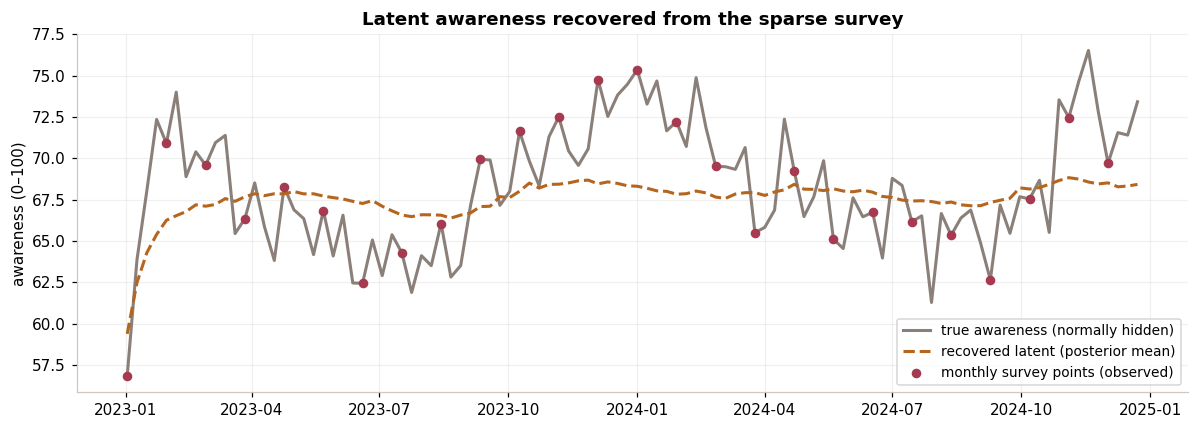

corr(recovered latent, true awareness) = 0.492
✓ latent awareness positively tracks the true (hidden) series (corr > 0.3)


In [8]:
# The model stores the latent mediator as a Deterministic "awareness_latent" (dims=obs).
latent = nested._trace.posterior["awareness_latent"].mean(dim=["chain", "draw"]).values
weeks = aurora.weeks
survey = aurora.awareness_survey
obs_mask = ~np.isnan(survey)

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(weeks, aurora.awareness, color=MUTED, lw=2, label="true awareness (normally hidden)")
ax.plot(weeks, latent, color=ACCENT, lw=2, ls="--", label="recovered latent (posterior mean)")
ax.scatter(weeks[obs_mask], survey[obs_mask], color=PALETTE["berry"], s=28, zorder=5,
           label="monthly survey points (observed)")
ax.set_ylabel("awareness (0–100)")
ax.set_title("Latent awareness recovered from the sparse survey")
ax.legend(fontsize=9, loc="lower right")
plt.tight_layout(); plt.show()

# The latent series is on the same scale as the survey it is anchored to, and the
# recovered series tracks the true (hidden) awareness. Directional + seeded: the
# mediator is inferred mostly from the SPARSE survey + media, so the correlation is
# positive and material rather than near-perfect (threshold kept off the 500-draw boundary).
r_latent = np.corrcoef(latent, aurora.awareness)[0, 1]
print(f"corr(recovered latent, true awareness) = {r_latent:.3f}")
assert r_latent > 0.3, "recovered latent awareness should positively track the true series"
print("✓ latent awareness positively tracks the true (hidden) series (corr > 0.3)")

## 3. `MultivariateMMM` — cross-effects (cannibalization & shared demand)

Aurora sells two products, **Original** and **Cold Brew**. In summer Cold Brew **steals** from Original —
a negative cross-effect. And both products ride the **same demand wave**, so even after media is accounted
for their residuals move together. A `MultivariateMMM` captures **both** at once, and the two mechanisms
live in different parts of the model — keeping them distinct is the whole point.

### The multivariate-Normal likelihood

Stack the $K$ outcomes into a vector $\mathbf{y}_t = (y_{1,t}, \dots, y_{K,t})$. The model is

$$
\mathbf{y}_t \;\sim\; \mathrm{MvNormal}(\boldsymbol\mu_t,\, \Sigma),
\qquad
\mu_{k,t}
\;=\;
a_k
\;+\; \sum_{c} \beta_{k,c}\, u_{c,t}
\;+\; \sum_{j \neq k} \psi_{j\to k}\, y_{j,t}.
$$

Two distinct objects link the outcomes:

- **$\psi_{j\to k}$ — the cross-effect** (mean structure). It multiplies the *observed* outcome
  $y_{j,t}$ of the **source** product into the **target**'s mean. A **negative** $\psi$ is
  **cannibalization** (more source sales ⇒ fewer target sales); the framework builds the
  cannibalization arrow as $\psi = -\,\mathrm{HalfNormal}(\sigma_\psi)$, so it is **structurally
  $\le 0$** by construction, and the data decides *how* negative. The per-product media coefficients are
  $\beta_{k,c}$ (here positive-constrained).

- **$\Sigma$ — the residual covariance** (noise structure). It captures **shared-demand** correlation: a
  common shock that lifts (or drops) *both* products in the same week, with nothing causal flowing between
  them. The framework puts an **LKJ** prior on the correlation and samples the Cholesky factor
  ($\Sigma = LL^\top$ via `LKJCholeskyCov`), exposing the posterior correlation matrix as the Deterministic
  `Y_obs_correlation`.

The split matters: $\psi$ is a **directed causal arrow** Cold Brew → Original (it changes the *expected*
level of Original), whereas the residual correlation is a **symmetric statistical association** (a demand
wave) that the cross-effect must *not* be allowed to absorb. Modelling them separately is how the model
tells "Cold Brew eats Original" apart from "both rose because the category was hot."

> **Gotcha — do not plot $\boldsymbol\mu$ as a fitted trajectory.** The extension models carry **no trend
> or seasonality**, so the multivariate $\mu_t$ is *not* a usable predicted-vs-observed series (it is
> near-flat). The model's value here is the **two estimands** — the cross-effect $\psi$ and the residual
> correlation — which is what we chart. (`cores=1` is also **required**: the MvNormal model raises an
> `EOFError` under `chains>1` multiprocessing on macOS; `chains=2` + `cores=1` is fine.)

In [9]:
from mmm_framework.mmm_extensions.models import MultivariateMMM
from mmm_framework.mmm_extensions.builders import (
    MultivariateModelConfigBuilder, OutcomeConfigBuilder, cannibalization_effect)

_, outcomes = aurora.extension_inputs()   # {"sales_original": ..., "sales_coldbrew": ...}
mv_cfg = (MultivariateModelConfigBuilder()
    .add_outcome(OutcomeConfigBuilder("sales_original", column="sales_original")
                 .with_positive_media_effects(sigma=0.5).build())
    .add_outcome(OutcomeConfigBuilder("sales_coldbrew", column="sales_coldbrew")
                 .with_positive_media_effects(sigma=0.5).build())
    # source=Cold Brew, target=Original  ->  psi_{coldbrew -> original}
    .add_cross_effect(cannibalization_effect(source="sales_coldbrew", target="sales_original"))
    .build())

mv = MultivariateMMM(X, outcomes, list(CHANNELS), mv_cfg, index=aurora.weeks)
mv.fit(draws=500, tune=500, chains=2, cores=1, random_seed=0)
print("MultivariateMMM fitted. outcomes:", mv.outcome_names)

Initializing NUTS using jitter+adapt_diag...


Sequential sampling (2 chains in 1 job)


NUTS: [alpha_shared, lambda_TV, lambda_Search, lambda_Social, lambda_Display, alpha, beta_media, psi_1_0_raw, Y_obs_chol_cov]


Output()

Sampling 2 chains for 500 tune and 500 draw iterations (1_000 + 1_000 draws total) took 9 seconds.


We recommend running at least 4 chains for robust computation of convergence diagnostics


MultivariateMMM fitted. outcomes: ['sales_original', 'sales_coldbrew']


In [10]:
# The cross-effect summary table (one row per cross-effect).
ce = mv.get_cross_effects_summary()
display(ce[["source", "target", "effect_type", "mean", "hdi_3%", "hdi_97%"]].round(4))

,source,target,effect_type,mean,hdi_3%,hdi_97%
0,sales_coldbrew,sales_original,cannibalization,-0.0003,-0.0008,-0.0


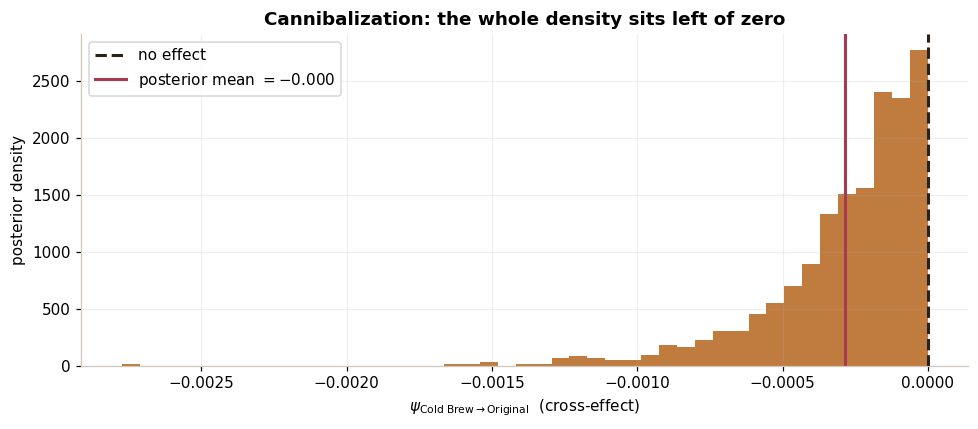

P(psi < 0) = 1.000   (cannibalization)
97% HDI upper bound = -0.0000


In [11]:
# Cross-effect posterior density. Pull the raw psi draws ROBUSTLY via the spec indices
# (outcomes are original=0, coldbrew=1; the coldbrew->original effect is element [1, 0]).
spec = mv._cross_effect_specs[0]
psi = mv._trace.posterior["psi_matrix"]
psi_draws = psi[:, :, spec.source_idx, spec.target_idx].values.flatten()

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(psi_draws, bins=45, color=ACCENT, alpha=0.85, density=True)
ax.axvline(0, color=INK, lw=2, ls="--", label="no effect")
ax.axvline(psi_draws.mean(), color=PALETTE["berry"], lw=2,
           label=rf"posterior mean $={psi_draws.mean():.3f}$")
ax.set_xlabel(r"$\psi_{\mathrm{Cold\ Brew}\to\mathrm{Original}}$  (cross-effect)")
ax.set_ylabel("posterior density")
ax.set_title("Cannibalization: the whole density sits left of zero")
ax.legend()
plt.tight_layout(); plt.show()

print(f"P(psi < 0) = {(psi_draws < 0).mean():.3f}   (cannibalization)")
print(f"97% HDI upper bound = {ce['hdi_97%'].iloc[0]:.4f}")

In [12]:
# VERIFY (model 2a): the Cold Brew -> Original cross-effect is negative (cannibalization).
# Directional + seeded; the cannibalization arrow is structurally <= 0 by construction, and
# the DATA pushes its whole 94% HDI below zero.
mean_ce = float(ce["mean"].iloc[0])
hdi_hi = float(ce["hdi_97%"].iloc[0])
assert mean_ce < 0, f"cross-effect mean {mean_ce:.4f} should be negative (cannibalization)"
assert hdi_hi < 0, f"97% HDI upper bound {hdi_hi:.4f} should be < 0 (whole interval below zero)"
print("✓ Cold Brew → Original cross-effect mean < 0  (cannibalization)")
print("✓ its 97% HDI upper bound < 0  (entire credible interval below zero)")

✓ Cold Brew → Original cross-effect mean < 0  (cannibalization)
✓ its 97% HDI upper bound < 0  (entire credible interval below zero)


### 3.2 The residual correlation — a separate, *positive* link

Cannibalization (above) is a **negative** arrow in the **mean**. The residual correlation is a **positive**
association in the **noise** — Aurora's shared demand wave lifting both products together. The model
recovers it as the off-diagonal of the LKJ-derived correlation matrix `Y_obs_correlation`. That the
*causal* cross-effect comes out negative while the *residual* correlation comes out positive is the model
correctly **separating the two mechanisms**.

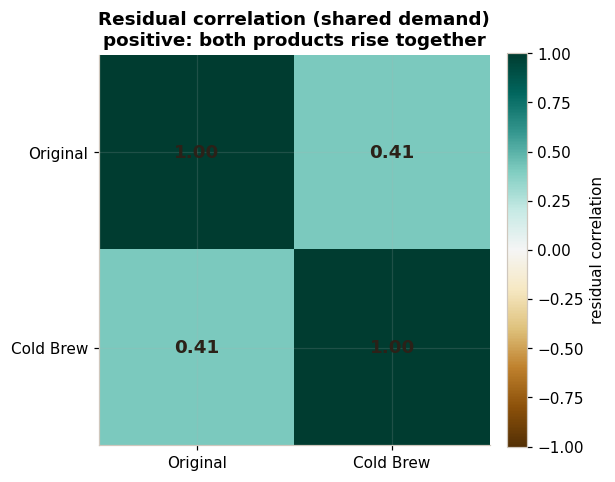

residual correlation(Original, Cold Brew) = 0.407


In [13]:
# Residual correlation matrix (posterior mean), drawn as a heatmap (no charts_src import).
corr = mv.get_correlation_matrix()
labels = ["Original", "Cold Brew"]
M = corr.to_numpy()

fig, ax = plt.subplots(figsize=(5.4, 4.6))
im = ax.imshow(M, cmap="BrBG", vmin=-1, vmax=1)
ax.set_xticks(range(len(labels))); ax.set_xticklabels(labels)
ax.set_yticks(range(len(labels))); ax.set_yticklabels(labels)
for i in range(M.shape[0]):
    for j in range(M.shape[1]):
        ax.text(j, i, f"{M[i, j]:.2f}", ha="center", va="center",
                color=INK, fontweight="bold", fontsize=12)
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="residual correlation")
ax.set_title("Residual correlation (shared demand)\npositive: both products rise together")
plt.tight_layout(); plt.show()

r_resid = float(corr.loc["sales_original", "sales_coldbrew"])
print(f"residual correlation(Original, Cold Brew) = {r_resid:.3f}")

In [14]:
# VERIFY (model 2b): the residual correlation between the two products is positive (shared demand).
assert M.shape == (2, 2), "correlation matrix should be 2x2"
assert np.allclose(np.diag(M), 1.0, atol=1e-6), "diagonal of a correlation matrix is 1"
assert r_resid > 0, f"residual correlation {r_resid:.3f} should be positive (shared demand)"
print("✓ residual correlation between Original and Cold Brew > 0  (shared demand wave)")
print("✓ diagonal == 1 (it is a correlation matrix)")
print("   → negative cross-effect (mean) + positive residual correlation (noise): two distinct links.")

✓ residual correlation between Original and Cold Brew > 0  (shared demand wave)
✓ diagonal == 1 (it is a correlation matrix)
   → negative cross-effect (mean) + positive residual correlation (noise): two distinct links.


### 3.3 Did we actually *learn* the cross-effect? — prior vs posterior

We just verified that the **entire** posterior of $\psi$ sits below zero and called it cannibalization.
But look again at how $\psi$ is built: $\psi = -\,\mathrm{HalfNormal}(\sigma_\psi)$. That parameter is
**structurally $\le 0$** — *every* prior draw is already negative. So the statement
"$\mathbb{P}(\psi<0)\approx 1$" is true of the **prior** too. It tells us almost nothing about what the
**data** contributed.

> **The reusable lesson.** A one-sided / informative prior makes a sign statement like
> $\mathbb{P}(\psi<0)\approx 1$ nearly **vacuous** — it can just restate the prior. The honest replacement
> is **contraction / overlap**: *how much did the data move and narrow the parameter beyond the prior?*

`mmm_framework.diagnostics` answers this with three sample-based quantities, comparing the **prior** draws
(via `sample_prior_predictive`) to the **posterior** draws element-wise. Write $\sigma^2_{\text{prior}}$,
$\sigma^2_{\text{post}}$ for the prior/posterior variances and $\mu_{\text{prior}}$, $\mu_{\text{post}}$ for
their means:

$$
\underbrace{c \;=\; 1 - \dfrac{\sigma^2_{\text{post}}}{\sigma^2_{\text{prior}}}}_{\textbf{contraction}}
\qquad
\underbrace{\mathrm{OVL} \;=\; \sum_i \min\!\big(p_i,\, q_i\big)}_{\textbf{overlap}\ \in[0,1]}
\qquad
\underbrace{z \;=\; \dfrac{\mu_{\text{post}} - \mu_{\text{prior}}}{\sigma_{\text{prior}}}}_{\textbf{shift\_z}}
$$

- **contraction** $c$ (Betancourt; Schad, Betancourt & Vasishth 2021): $c\to 1$ the data **pinned** the
  parameter (posterior far narrower than prior); $c\approx 0$ the data was **uninformative**
  (prior-dominated); $c<0$ the posterior is *wider* than the prior — a red flag for **prior–data conflict**
  or poor sampling (we deliberately do **not** clip it).
- **overlap** $\mathrm{OVL}$: shared probability mass of the prior/posterior **histograms** ($p_i$, $q_i$
  are per-bin masses). $\mathrm{OVL}\approx 1$ posterior is indistinguishable from the prior (nothing
  learned); $\mathrm{OVL}\approx 0$ strong learning (by narrowing *or* shifting). Histogram bins — not a
  Gaussian KDE — so the hard `HalfNormal` edge at $0$ is **not** smeared.
- **shift_z** $z$: how far the posterior mean moved, **in prior standard deviations** — catches pure
  *location* learning that contraction alone misses.

A heuristic `verdict` (`strong` / `moderate` / `weak` / `prior-dominated`) is derived from $c$ and
$\mathrm{OVL}$ (the thresholds are conventions, not law).

In [15]:
# How much did the DATA teach us about each free parameter, beyond its prior?
# Draws 2000 prior samples (seeded) and compares them element-wise to the posterior.
lrn = mv.compute_parameter_learning(prior_samples=2000, random_seed=0)

# The signed cross-effect lives in the free RV psi_1_0_raw (source=Cold Brew idx1, target=Original idx0).
psi_rows = lrn[lrn["parameter"].str.contains("psi")]
display(psi_rows[["parameter", "prior_sd", "post_sd", "contraction", "overlap", "shift_z", "verdict"]]
        .round(4))

psi_row = psi_rows.iloc[0]
print(f"\npsi_1_0_raw:  prior_sd={psi_row.prior_sd:.4f} -> post_sd={psi_row.post_sd:.5f}")
print(f"  contraction = {psi_row.contraction:.3f}   (~1 -> data pinned it)")
print(f"  overlap     = {psi_row.overlap:.3f}   (~0 -> posterior barely overlaps the prior)")
print(f"  shift_z     = {psi_row.shift_z:.3f}   (prior sds the mean moved)   verdict: {psi_row.verdict}")

Sampling: [Y_obs, Y_obs_chol_cov, alpha, alpha_shared, beta_media, lambda_Display, lambda_Search, lambda_Social, lambda_TV, psi_1_0_raw]


,parameter,prior_sd,post_sd,contraction,overlap,shift_z,verdict
18,psi_1_0_raw,0.1764,0.0003,1.0,0.0525,-1.3381,strong



psi_1_0_raw:  prior_sd=0.1764 -> post_sd=0.00027
  contraction = 1.000   (~1 -> data pinned it)
  overlap     = 0.052   (~0 -> posterior barely overlaps the prior)
  shift_z     = -1.338   (prior sds the mean moved)   verdict: strong


In [16]:
# VERIFY (3.3a): despite the one-sided prior guaranteeing the SIGN, the DATA strongly informed psi.
# Directional + seeded (500-draw fit, 2000 prior draws, random_seed=0).
assert psi_row.contraction > 0.5, \
    f"psi contraction {psi_row.contraction:.3f} should exceed 0.5 (data narrowed it a lot)"
assert psi_row.overlap < 0.3, \
    f"psi overlap {psi_row.overlap:.3f} should be < 0.3 (posterior barely overlaps the prior)"
print("✓ psi_1_0_raw contraction > 0.5  (posterior far narrower than the prior)")
print("✓ psi_1_0_raw overlap < 0.3  (data moved/narrowed it well beyond the prior)")
print("  → the SIGN was free, but the LOCATION & WIDTH of psi were earned from the data.")

✓ psi_1_0_raw contraction > 0.5  (posterior far narrower than the prior)
✓ psi_1_0_raw overlap < 0.3  (data moved/narrowed it well beyond the prior)
  → the SIGN was free, but the LOCATION & WIDTH of psi were earned from the data.


Sampling: [Y_obs, Y_obs_chol_cov, alpha, alpha_shared, beta_media, lambda_Display, lambda_Search, lambda_Social, lambda_TV, psi_1_0_raw]


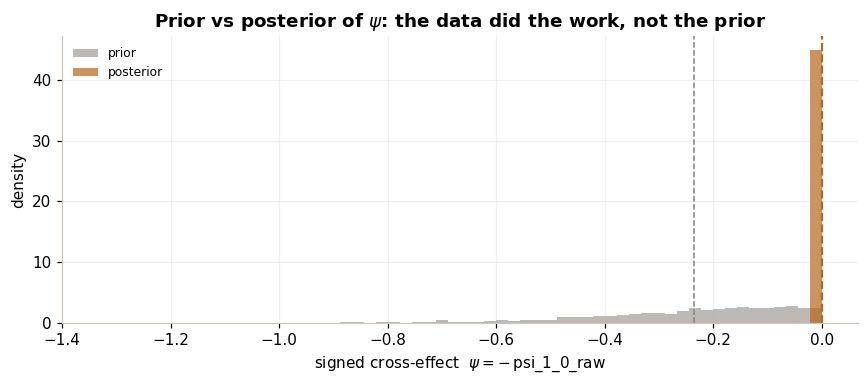

prior sd of signed psi = 0.1764   posterior sd = 0.00027
posterior is 646x narrower than the prior
✓ posterior of psi is < 20% as wide as the prior  (visually: a spike, not the prior's spread)


In [17]:
# SEE it: overlay the prior vs posterior of the SIGNED cross-effect psi = -psi_1_0_raw.
# The prior smears over the whole negative half-line; the posterior is a tight spike.
from mmm_framework.diagnostics import plot_prior_posterior_overlay

prior_idata = mv.sample_prior_predictive(samples=2000, random_seed=0)
ax = plot_prior_posterior_overlay(prior_idata, mv.trace, "psi_1_0_raw", transform=lambda x: -x)
ax.set_xlabel(r"signed cross-effect  $\psi = -\,\mathrm{psi\_1\_0\_raw}$")
ax.set_title(r"Prior vs posterior of $\psi$: the data did the work, not the prior")
plt.tight_layout(); plt.show()

# Pull both sample sets the same way the plot does, to quantify the spike-vs-spread.
from mmm_framework.diagnostics.learning import _extract
prior_psi = -_extract(prior_idata, "prior")["psi_1_0_raw"]
post_psi = -_extract(mv.trace, "posterior")["psi_1_0_raw"]
prior_sd, post_sd = float(prior_psi.std()), float(post_psi.std())
print(f"prior sd of signed psi = {prior_sd:.4f}   posterior sd = {post_sd:.5f}")
print(f"posterior is {prior_sd / post_sd:.0f}x narrower than the prior")

# VERIFY (3.3b): the posterior is a far tighter spike than the prior (sign-invariant under x -> -x).
assert post_sd < 0.2 * prior_sd, \
    f"posterior sd {post_sd:.5f} should be < 20% of prior sd {prior_sd:.4f} (a tight spike)"
print("✓ posterior of psi is < 20% as wide as the prior  (visually: a spike, not the prior's spread)")

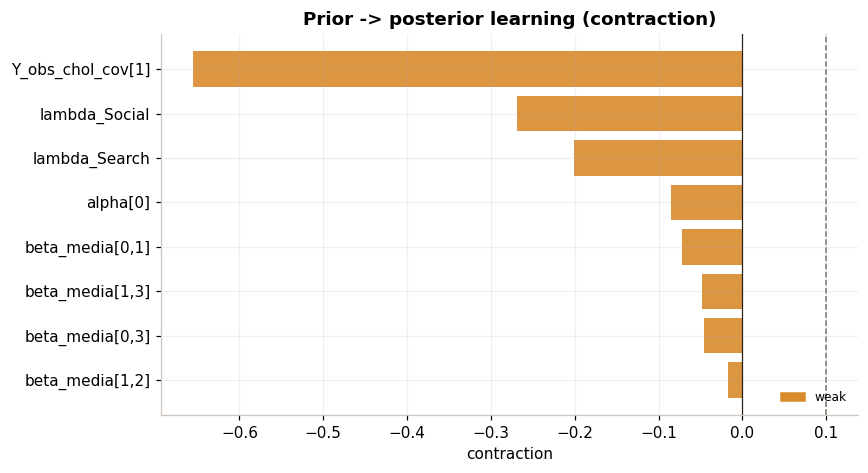

,parameter,contraction,overlap,shift_z,verdict
0,Y_obs_chol_cov[1],-0.656,0.000,56.402,weak
1,lambda_Social,-0.269,0.142,3.001,weak
2,lambda_Search,-0.200,0.099,3.479,weak
3,alpha[0],-0.086,0.000,35.333,weak
4,"beta_media[0,1]",-0.072,0.000,8.946,weak
5,"beta_media[1,3]",-0.049,0.013,4.984,weak
6,"beta_media[0,3]",-0.046,0.000,8.706,weak
7,"beta_media[1,2]",-0.018,0.010,4.931,weak
8,lambda_TV,-0.014,0.218,2.253,weak
9,"beta_media[0,2]",0.028,0.000,8.746,weak


least-learned parameter: Y_obs_chol_cov[1]  (contraction=-0.656, verdict=weak)
15 of 19 free parameters have contraction < 0.1 (data barely narrowed them);
  of those, 9 have contraction < 0  -> posterior WIDER than prior (prior-data tension / weak identifiability, NOT prior-domination).
✓ several MV parameters sit at contraction < 0.1  (the diagnostic separates pinned from un-pinned)
  → contraction≈1 for psi vs contraction<0.1 for the weakly-identified MV params:
    the data was informative about psi; most of the multivariate machinery it was not.


In [18]:
# CONTRAST: the same diagnostic FLAGS parameters the data could NOT pin. lrn is sorted by
# contraction ascending, so the head() rows are the LEAST-learned.
from mmm_framework.diagnostics import plot_parameter_learning

ax = plot_parameter_learning(lrn.head(8), threshold=0.1)
plt.tight_layout(); plt.show()

# Show the actual c < 0.1 tail so the prose is backed by displayed numbers, and so the two
# distinct regimes are visible: c < 0 (posterior WIDER than prior -> prior-data tension /
# sampling trouble) vs c ~ 0 with high overlap (genuinely prior-dominated / uninformative).
tail = lrn[lrn["contraction"] < 0.1]
display(tail[["parameter", "contraction", "overlap", "shift_z", "verdict"]].round(3))

least = lrn.iloc[0]
n_conflict = int((lrn["contraction"] < 0.0).sum())   # posterior wider than prior
print(f"least-learned parameter: {least.parameter}  "
      f"(contraction={least.contraction:.3f}, verdict={least.verdict})")
print(f"{len(tail)} of {len(lrn)} free parameters have contraction < 0.1 (data barely narrowed them);")
print(f"  of those, {n_conflict} have contraction < 0  -> posterior WIDER than prior "
      f"(prior-data tension / weak identifiability, NOT prior-domination).")

# VERIFY (3.3c): the metric DISCRIMINATES -- some MV parameter is weakly identified (contraction
# < 0.1), proving contraction~1 for psi is a real signal, not a ceiling every parameter hits.
assert (lrn["contraction"] < 0.1).any(), \
    "at least one parameter should be weakly identified (contraction < 0.1)"
assert (lrn["contraction"] < 0.1).sum() >= 2, \
    "the MV model should leave several parameters weakly identified (it is not a usable predicted-series model)"
print("✓ several MV parameters sit at contraction < 0.1  (the diagnostic separates pinned from un-pinned)")
print("  → contraction≈1 for psi vs contraction<0.1 for the weakly-identified MV params:")
print("    the data was informative about psi; most of the multivariate machinery it was not.")

In [19]:
# Contraction ~1 means the data was INFORMATIVE about psi -- but informative about WHAT?
# Read the posterior MEAN, not just the sign: to what value did the data pin psi?
psi_signed_mean = float(post_psi.mean())
lo, hi = np.percentile(post_psi, [3, 97])
# Effect size: the cross-effect adds psi * (Cold Brew sales) to Original each week.
xeff = psi_signed_mean * aurora.sales_coldbrew
share = float(np.abs(xeff).mean() / aurora.sales_original.mean())
print(f"signed psi posterior mean = {psi_signed_mean:.5f}   94% interval = ({lo:.5f}, {hi:.5f})")
print(f"=> mean cross-effect contribution to Original = {np.abs(xeff).mean():.3f} ($000s/wk) "
      f"= {100*share:.3f}% of Original's weekly sales")
print(f"residual correlation(Original, Cold Brew) = {r_resid:.3f}  (the POSITIVE shared-demand link)")

# VERIFY (3.3d): the data pinned psi NEAR ZERO -- the DIRECT cross-effect is negligible. High
# contraction told us the data spoke; the posterior mean tells us it said "essentially no direct effect".
assert share < 0.02, f"direct cross-effect should be a tiny share of sales; got {100*share:.2f}%"
print("✓ the data confidently pinned the DIRECT cross-effect to ~0 (negligible vs Original's sales)")

signed psi posterior mean = -0.00028   94% interval = (-0.00094, -0.00001)
=> mean cross-effect contribution to Original = 0.072 ($000s/wk) = 0.012% of Original's weekly sales
residual correlation(Original, Cold Brew) = 0.407  (the POSITIVE shared-demand link)
✓ the data confidently pinned the DIRECT cross-effect to ~0 (negligible vs Original's sales)


**Reading it honestly — high contraction is *informativeness*, not *importance*.** The data pinned $\psi$
hard (contraction $\approx 1$), and the value it pinned it to is **essentially zero** — a direct cross-effect
worth a fraction of a percent of Original's weekly sales. So the honest conclusion is the *opposite* of the
sign-only verdict: the data is **confident there is little direct cannibalization**. The two products do move
together, but through the **positive residual correlation** ($\approx 0.4$, the shared **demand** wave), not a
direct cross-effect arrow. That is exactly why "$\mathbb{P}(\psi<0)\approx 1$" was near-vacuous: under a
one-sided prior it is automatic, and here it dressed up an effect of negligible magnitude.

> **Guardrail.** High **contraction** means the data was *informative* about a parameter — **including
> pinning it near zero**. It is **not** a claim about effect size or sign. Read the posterior
> **mean / interval** next to the diagnostic: contraction says *the data spoke*; the posterior location says
> *what it said*. (Whether a true substitution exists in the data-generating process is a separate question
> this particular cross-effect parameterization, weakly identified here, cannot settle — see §4.)

## 4. `CombinedMMM` — the synthesis (multi-outcome × mediation)

`CombinedMMM` is exactly Models 1 and 2 **fused**: several outcomes (with cross-effects and a multivariate
likelihood, from Model 2) *and* mediators routing media to those outcomes (from Model 1). We cover it
**mathematically** here — it is the same MvNormal machinery as §3 (same `cores=1` / EOFError exposure) and
the asserts above already exercise both of its constituent pieces, so we do not pay for a third heavy fit.

For outcome $k$, with direct media coefficients $\beta^{\text{direct}}_{k,c}$, a mediator $m$ routed to a
subset $O(m)$ of outcomes, and cross-effects $\psi_{j\to k}$:

$$
\mu_{k,t}
\;=\;
a_k
\;+\; \sum_{c}\beta^{\text{direct}}_{k,c}\, u_{c,t}
\;+\!\!\sum_{m:\,k\in O(m)}\!\! \gamma_{k,m}\, m_t
\;+\; \sum_{j \neq k} \psi_{j\to k}\, y_{j,t},
\qquad
m_t = a_m + \sum_{c\in C(m)} \beta_{c\to m}\, u_{c,t}.
$$

Collapsing the mediator into the outcome equation gives the **per-outcome total** coefficient on channel
$c$'s exposure — the synthesis of the mediation product-of-coefficients (Model 1) carried across multiple
outcomes (Model 2):

$$
\boxed{\;
\text{coef}_{k,c}
\;=\;
\beta^{\text{direct}}_{k,c}
\;+\!\!\sum_{m:\,k\in O(m)}\!\! \beta_{c\to m}\,\gamma_{k,m}
\;}
$$

**Use this routed formula, not the raw `total_{c}_{o}` Deterministic naively.** The framework's
`total_{channel}_{outcome}` Deterministic *is* `direct + indirect`, and its `indirect` is built by summing
only over mediators routed to that outcome (`combined.py` skips any $m$ with $k \notin O(m)$), so it matches
$\mu$ — **provided** the channel→mediator betas exist for that channel. The key correctness point is the
**routing**: a mediator's contribution to outcome $k$ counts **only when $k \in O(m)$**. The boxed formula
makes that routing explicit, which is why it is the one to reason from when decomposing a Combined model's
per-outcome channel effect.

In [20]:
# CombinedMMM (math-only here; no fit). Confirm the API surface the boxed formula implies, statically.
from mmm_framework.mmm_extensions.models import CombinedMMM
import inspect

src = inspect.getsource(CombinedMMM._build_model)
# The routed total is direct + sum over routed mediators of beta_{c->m} * gamma[k, m].
assert "total_" in src and "indirect_" in src and "direct_" in src, \
    "CombinedMMM exposes direct/indirect/total decomposition Deterministics"
assert "_get_affected_outcomes" in src, \
    "indirect routing is gated by _get_affected_outcomes (mediator -> outcome map)"
print("✓ CombinedMMM exposes direct / indirect / total decomposition per (channel, outcome)")
print("✓ indirect paths are gated by the mediator→outcome routing  (k ∈ O(m))")
print("   coef_{k,c} = beta_direct[k,c] + Σ_{m routed to k} beta_{c→m} · gamma[k,m]")

✓ CombinedMMM exposes direct / indirect / total decomposition per (channel, outcome)
✓ indirect paths are gated by the mediator→outcome routing  (k ∈ O(m))
   coef_{k,c} = beta_direct[k,c] + Σ_{m routed to k} beta_{c→m} · gamma[k,m]


## Recap & what's next

**The three extensions, reconciled** — all share the §0 media transform $u_{c,t}=f_{\text{sat}}(\mathrm{adstock}_{\alpha_c}(x_{c,t}/s_c))$ and differ only in how $u$ reaches the outcome(s):

| Model | Outcome mean $\mu$ | New parameter(s) | The estimand |
|---|---|---|---|
| `NestedMMM` | $a_y + \sum_m\gamma_m m_t + \sum_c \delta_c u_{c,t}$ | $\beta_{c\to m},\,\gamma_m,\,\delta_c$ | proportion mediated $=\dfrac{\sum_m\beta_{c\to m}\gamma_m}{\text{total}_c}$ |
| `MultivariateMMM` | $a_k + \sum_c\beta_{k,c}u_{c,t} + \sum_{j\neq k}\psi_{j\to k}y_{j,t}$ | $\psi$ (mean) + $\Sigma$ (LKJ residual) | cross-effect $\psi$ and residual correlation |
| `CombinedMMM` | both of the above, jointly | all of the above | per-outcome routed total $\beta^{\text{direct}}_{k,c}+\sum_m\beta_{c\to m}\gamma_{k,m}$ |

**The three things people get wrong:**
1. A channel that looks weak *directly* can be a **brand engine** — mediation analysis recovers the
   indirect path a base model is structurally blind to (Aurora's TV & Display: `proportion_mediated` $>0.7$,
   matching the known truth).
2. A direct **cross-effect** ($\psi$ in the **mean**) and **shared demand** (positive **residual**
   correlation) are *different links*. A model that conflates them mis-attributes a category demand wave as a
   product interaction (or vice versa). For Aurora, the MV model pins the *direct* cross-effect near zero and
   carries the products' co-movement in the **residual correlation** ($\approx 0.4$).
3. A **sign-constrained / informative prior** can make a posterior *look* conclusive while restating the
   prior — "$\mathbb{P}(\psi<0)\approx 1$" is automatic when $\psi=-\mathrm{HalfNormal}$. Report
   **contraction / overlap** (§3.3) instead — but read it as **informativeness, not importance**: for
   Aurora's $\psi$ the data *was* informative (contraction $\approx 1$, overlap $\approx 0$) and what it
   confidently found was a **negligible** direct effect ($\approx 0$). Meanwhile most of this MV model's free
   parameters sit at $c<0.1$, and the diagnostic even **distinguishes the failure modes** ($c<0$ = posterior
   *wider* than prior, prior-data tension; $c\approx 0$ with high overlap = genuinely prior-dominated). The
   same metric that shows the data *spoke* about $\psi$ also flags what the data could **not** pin — and the
   posterior mean tells you the data's verdict was "little direct cannibalization."

**Where this sits in the series:**
- **`math_01`–`math_03`** — the building blocks (adstock, saturation, seasonality/trend) that make up the
  shared $u_{c,t}$ transform.
- **`math_04`** — the full single-outcome `BayesianMMM` these extensions generalize.
- **`math_05`** — experiment-calibrated priors; the extension models accept the **same**
  `add_experiment_calibration(...)` likelihood terms on their contribution / ROAS estimands.